# Confronto fra Quicksort e Counting Sort

---

## Introduzione



## Quicksort

### Descrizione


### Complessità


### Algoritmo

In [1]:
def partition(seq, start, stop):
    pivotIndex = start
    pivot = seq[pivotIndex]
    i = start + 1
    j = stop - 1

    while i <= j:
        while i <= j and seq[i] <= pivot:
            i += 1
        while i <= j and pivot < seq[j]:
            j -= 1

        if i < j:
            tmp = seq[i]
            seq[i] = seq[j]
            seq[j] = tmp
            i += 1
            j -= 1

    seq[pivotIndex] = seq[j]
    seq[j] = pivot

    return j

In [2]:
def quicksort(seq, start, stop):
    if start >= stop - 1:
        return

    pivotIndex = partition(seq, start, stop)

    quicksort(seq, start, pivotIndex)
    quicksort(seq, pivotIndex + 1, stop)

### Esempio di Utilizzo

In [3]:
seq = [23, 61, 93, 84, 16, 56, 46, 2, 55, 95]
quicksort(seq, 0, len(seq)-1)
print('La lista ordinata è:', seq)

La lista ordinata è: [2, 16, 23, 46, 55, 56, 61, 84, 93, 95]


## Counting Sort

### Descrizione

### Complessità

### Algoritmo


In [4]:
def counting_sort(seq):
    size = len(seq)
    maxval = max(seq)
    countSeq = [0] * (maxval + 1)

    # Conto la ricorrenza di ogni elemento
    for v in seq:
        countSeq[v] += 1

    for i in range(1, maxval + 1):
        countSeq[i] += countSeq[i - 1]

    # Costruisco il risultato
    ans = [0] * size
    
    for i in range(size - 1, -1, -1):
        v = seq[i]
        ans[countSeq[v] - 1] = v
        countSeq[v] -= 1

    return ans

### Esempio di Utilizzo

In [5]:
seq = [43, 35, 16, 87, 74, 45, 100, 64, 50, 30]
ordered_list = counting_sort(seq)
print('La lista ordinata è:', ordered_list)

La lista ordinata è: [16, 30, 35, 43, 45, 50, 64, 74, 87, 100]


---

## Esperimento

Le liste hanno tutte stessa dimensione.
1. Test su lista casuale con range molto ampio di valori possibili
2. Test su lista casuale con range ristretto di valori possibili
3. Test su lista ordinata


Esperimento numero 1:


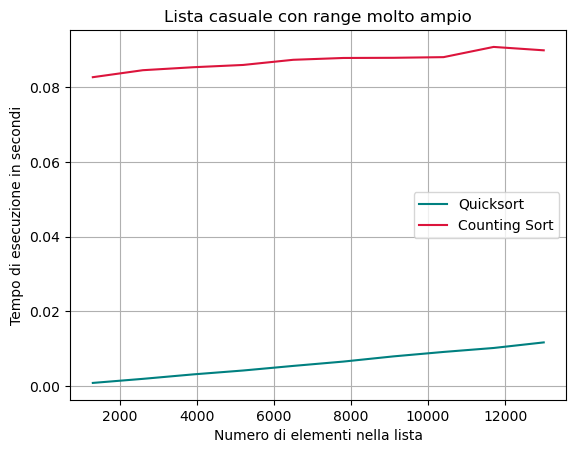

Esperimento numero 2:


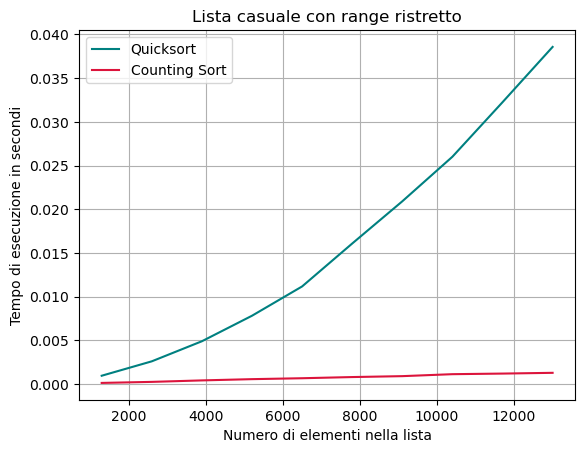

Esperimento numero 3:


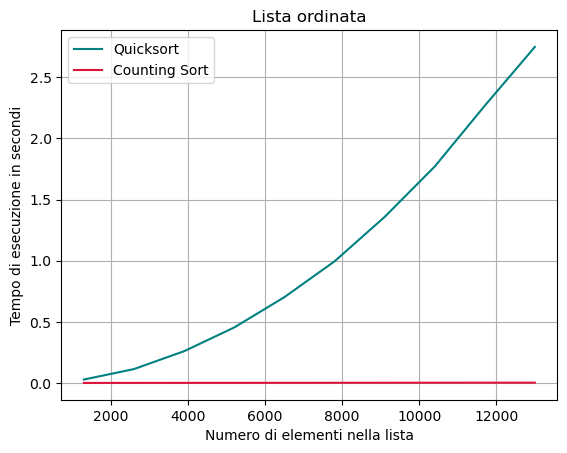

In [6]:
import random
from timeit import default_timer as timer
import matplotlib.pyplot as plt
import sys
sys.setrecursionlimit(10 ** 9)

# Creo la lista completamente randomizzata su un range molto ampio
def big_range_list(size):
    return random.choices(range(1, 1_000_001), k=size)
    
# Creo una lista di grande dimensione ma con range ristretto e valori ripetuti
def small_range_list(size):
    return random.choices(range(1, 101), k=size)

# Creo la lista ordinata in modo crescente
def ordered_list(size):
    return list(range(size))

def experiment(seq_type_func, size, iterations, name):
    time_quicksort = []
    time_counting_sort = []
    size_sampling = []
    times = []
    repeats = 3

    seq_max = seq_type_func(size * iterations)

    for i in range(iterations):
        x = size * (i + 1)
        size_sampling.append(x)
        seq = seq_max[:x]
        
        # print('Campionando il tempo con lista di dimensione', x, '')

        # Eseguo i test 3 volte per ogni dimensione e prendo la media per attenuare le fluttuazioni
        
        # Comincio il test per il quicksort
        times.clear()
        for j in range(repeats):
            tmp = seq.copy()
            start = timer()
            quicksort(tmp, 0, len(tmp) - 1)
            end = timer()
            times.append(end - start)
        time_quicksort.append(sum(times) / repeats)
       
        # Comincio il test per il counting sort
        times.clear()
        for j in range(repeats):
            start = timer()
            counting_sort(seq) #Non occorre fare una copia della lista per il counting sort
            end = timer()
            times.append(end - start)
        time_counting_sort.append(sum(times) / repeats)
    
    plt.plot(size_sampling, time_quicksort, label = 'Quicksort', color = 'teal')
    plt.plot(size_sampling, time_counting_sort, label = 'Counting Sort', color = 'crimson')
    plt.xlabel('Numero di elementi nella lista')
    plt.ylabel('Tempo di esecuzione in secondi')
    plt.title(label = name)
    plt.grid(True)
    plt.legend()
    plt.show()

def main():
    size = 1300
    iterations = 10

    print('Esperimento numero 1:')
    experiment(big_range_list, size, iterations, 'Lista casuale con range molto ampio')
    
    print('Esperimento numero 2:')
    experiment(small_range_list, size, iterations, 'Lista casuale con range ristretto')
    
    print('Esperimento numero 3:')
    experiment(ordered_list, size, iterations, 'Lista ordinata')

    
main()

---

## Conclusioni






## Bibliografia e Sitografia

- [Generate a random list in python - GeeksforGeeks](https://www.geeksforgeeks.org/python/generating-random-number-list-in-python/)
- [Counting sort - Wikipedia](https://en.wikipedia.org/wiki/Counting_sort)
- [Counting sort - GeeksforGeeks](https://www.geeksforgeeks.org/dsa/counting-sort/)
- [Change plot color - Matplotlib Documentation](https://matplotlib.org/stable/users/explain/colors/colors.html)